In [27]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from MoleculeACE.benchmark.utils import Data, calc_rmse, calc_cliff_rmse
from MoleculeACE.benchmark.const import Descriptors
from MoleculeACE.models import (
    RF, SVM, GBM, KNN, MLP,
    GCN, MPNN, AFP, GAT,
    CNN, LSTM, Transformer
)

In [28]:
# Directories
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "Data"
RESULTS_DIR = PROJECT_ROOT / "Results"
RESULTS_DIR.mkdir(exist_ok=True)

prepared_file = DATA_DIR / "CHEMBL1978_prepared.csv"

# Load using MoleculeACE Data class
data = Data(str(prepared_file))

print("✓ Dataset Loaded Successfully")
print(f"Train size: {len(data.y_train)}")
print(f"Test size: {len(data.y_test)}")

✓ Dataset Loaded Successfully
Train size: 205
Test size: 54


In [29]:
ml_combinations = {
    Descriptors.ECFP: [RF, SVM, GBM, KNN, MLP],
    Descriptors.MACCS: [RF, SVM, GBM, KNN],
    Descriptors.PHYSCHEM: [RF, SVM, GBM, KNN],
    Descriptors.WHIM: [RF, SVM, GBM, KNN],
    Descriptors.GRAPH: [GCN, MPNN, AFP, GAT],
    Descriptors.TOKENS: [Transformer],
    Descriptors.SMILES: [CNN, LSTM]
    }


In [30]:
custom_hyperparameters = {

    # ---------------- RF ----------------
    "RF_ECFP": {"n_estimators": 1000},
    "RF_MACCS": {"n_estimators": 500},
    "RF_PHYSCHEM": {"n_estimators": 500},
    "RF_WHIM": {"n_estimators": 500},

    # ---------------- GBM ----------------
    "GBM_ECFP": {
        "learning_rate": 0.1,
        "max_depth": 5,
        "max_features": "sqrt",
        "max_leaf_nodes": None,
        "min_samples_leaf": 1,
        "min_samples_split": 2,
        "n_estimators": 400
    },
    "GBM_MACCS": {
        "learning_rate": 0.1,
        "max_depth": 6,
        "max_features": "sqrt",
        "max_leaf_nodes": None,
        "min_samples_leaf": 1,
        "min_samples_split": 2,
        "n_estimators": 400
    },
    "GBM_PHYSCHEM": {
        "learning_rate": 0.1,
        "max_depth": 6,
        "max_features": "sqrt",
        "max_leaf_nodes": None,
        "min_samples_leaf": 1,
        "min_samples_split": 2,
        "n_estimators": 200
    },
    "GBM_WHIM": {
        "learning_rate": 0.1,
        "max_depth": 6,
        "max_features": "sqrt",
        "max_leaf_nodes": None,
        "min_samples_leaf": 1,
        "min_samples_split": 2,
        "n_estimators": 200
    },

    # ---------------- SVM ----------------
    "SVM_ECFP": {"C": 10, "epsilon": 0.1, "gamma": 0.01, "kernel": "rbf"},
    "SVM_MACCS": {"C": 10, "epsilon": 0.1, "gamma": 0.1, "kernel": "rbf"},
    "SVM_PHYSCHEM": {"C": 100, "epsilon": 0.1, "gamma": 0.1, "kernel": "rbf"},
    "SVM_WHIM": {"C": 1, "epsilon": 0.1, "gamma": 0.01, "kernel": "rbf"},

    # ---------------- KNN ----------------
    "KNN_ECFP": {"metric": "euclidean", "n_neighbors": 5, "weights": "distance"},
    "KNN_MACCS": {"metric": "euclidean", "n_neighbors": 3, "weights": "distance"},
    "KNN_PHYSCHEM": {"metric": "euclidean", "n_neighbors": 11, "weights": "distance"},
    "KNN_WHIM": {"metric": "euclidean", "n_neighbors": 11, "weights": "distance"},

    # ---------------- MLP ----------------
    "MLP_ECFP": {
        "dropout": 0,
        "epochs": 131,
        "hidden": 1024,
        "lr": 5.0e-06,
        "n_layers": 3
    },

    # ---------------- GRAPH MODELS ----------------
    "GCN_GRAPH": {
        "dropout": 0,
        "epochs": 184,
        "fc_hidden": 128,
        "lr": 5.0e-05,
        "n_conv_layers": 4,
        "n_fc_layers": 3,
        "node_hidden": 512,
        "transformer_hidden": 64
    },

    "MPNN_GRAPH": {
        "dropout": 0,
        "edge_hidden": 128,
        "epochs": 56,
        "fc_hidden": 128,
        "lr": 0.0005,
        "message_steps": 4,
        "n_fc_layers": 3,
        "node_hidden": 128,
        "transformer_hidden": 256
    },

    "AFP_GRAPH": {
        "dropout": 0,
        "epochs": 89,
        "hidden_channels": 256,
        "lr": 0.0005,
        "num_layers": 3,
        "num_timesteps": 3
    },

    "GAT_GRAPH": {
        "dropout": 0,
        "epochs": 190,
        "fc_hidden": 128,
        "gatv2": False,
        "lr": 5.0e-05,
        "n_fc_layers": 1,
        "n_gat_layers": 3,
        "node_hidden": 512,
        "transformer_hidden": 128
    },

    # ---------------- SMILES MODELS ----------------
    "CNN_SMILES": {
        "epochs": 32,
        "hidden": 1024,
        "kernel_size": 4,
        "lr": 5.0e-05
    },

    "LSTM_SMILES": {
        "lr": 0.0005,
        "hidden_0": 1024,
        "hidden_1": 256,
        "dropout": 0.4
    },

    # ---------------- TRANSFORMER ----------------
    "Transformer_TOKENS": {
        "lr": 0.0005
    },
}

In [31]:

results = []

print("="*70)
print("STARTING ML BENCHMARK")
print("="*70)

for descriptor, models in ml_combinations.items():

    print(f"\nDescriptor: {descriptor.name}")
    data.featurize_data(descriptor)

    for model_class in models:

        model_name = model_class.__name__
        print(f"  Training {model_name}...")

        try:
            key = f"{model_name}_{descriptor.name}"
            hyperparams = custom_hyperparameters.get(key, {}).copy()

            epochs = hyperparams.pop("epochs", None)

            model = model_class(**hyperparams)

            if epochs:
                model.train(data.x_train, data.y_train, epochs=epochs)
            else:
                model.train(data.x_train, data.y_train)

            y_pred = model.predict(data.x_test)

            rmse = calc_rmse(data.y_test, y_pred)
            cliff_rmse = calc_cliff_rmse(
                y_test_pred=y_pred,
                y_test=data.y_test,
                cliff_mols_test=data.cliff_mols_test
            )

            results.append({
                "Descriptor": descriptor.name,
                "Model": model_name,
                "RMSE": rmse,
                "Cliff_RMSE": cliff_rmse
            })

            print(f"    ✓ RMSE: {rmse:.4f} | Cliff RMSE: {cliff_rmse:.4f}")

        except Exception as e:
            print(f"    ✗ Failed: {e}")

STARTING ML BENCHMARK

Descriptor: ECFP
  Training RF...


[15:02:00] DEPRECATION WARNING: please use MorganGenerator
[15:02:00] DEPRECATION WARNING: please use MorganGenerator
[15:02:00] DEPRECATION WARNING: please use MorganGenerator
[15:02:00] DEPRECATION WARNING: please use MorganGenerator
[15:02:00] DEPRECATION WARNING: please use MorganGenerator
[15:02:00] DEPRECATION WARNING: please use MorganGenerator
[15:02:00] DEPRECATION WARNING: please use MorganGenerator
[15:02:00] DEPRECATION WARNING: please use MorganGenerator
[15:02:00] DEPRECATION WARNING: please use MorganGenerator
[15:02:00] DEPRECATION WARNING: please use MorganGenerator
[15:02:00] DEPRECATION WARNING: please use MorganGenerator
[15:02:00] DEPRECATION WARNING: please use MorganGenerator
[15:02:00] DEPRECATION WARNING: please use MorganGenerator
[15:02:00] DEPRECATION WARNING: please use MorganGenerator
[15:02:00] DEPRECATION WARNING: please use MorganGenerator
[15:02:00] DEPRECATION WARNING: please use MorganGenerator
[15:02:00] DEPRECATION WARNING: please use MorganGenerat

    ✓ RMSE: 0.9625 | Cliff RMSE: 1.2652
  Training SVM...
    ✓ RMSE: 0.9112 | Cliff RMSE: 1.1614
  Training GBM...
    ✓ RMSE: 0.9151 | Cliff RMSE: 1.1513
  Training KNN...
    ✓ RMSE: 0.9447 | Cliff RMSE: 1.3768
  Training MLP...
    ✗ Failed: '>=' not supported between instances of 'int' and 'NoneType'

Descriptor: MACCS
  Training RF...
    ✓ RMSE: 1.0377 | Cliff RMSE: 1.3082
  Training SVM...
    ✓ RMSE: 1.0195 | Cliff RMSE: 1.2739
  Training GBM...
    ✓ RMSE: 1.0536 | Cliff RMSE: 1.2244
  Training KNN...
    ✓ RMSE: 1.0135 | Cliff RMSE: 1.2884

Descriptor: PHYSCHEM
  Training RF...
    ✓ RMSE: 1.0375 | Cliff RMSE: 1.3392
  Training SVM...
    ✓ RMSE: 0.8857 | Cliff RMSE: 1.0913
  Training GBM...
    ✓ RMSE: 1.0517 | Cliff RMSE: 1.3305
  Training KNN...
    ✓ RMSE: 1.0677 | Cliff RMSE: 1.3926

Descriptor: WHIM


 92%|█████████▏| 188/205 [00:24<00:05,  3.31it/s]

failed first attempt for molecule C=CC1O[C@]2(O)CC[C@]13C(=CC[C@@H]1[C@@H]3CC[C@]3(C)C(=O)CC[C@@H]13)C2, trying for more embedding attempts


100%|██████████| 54/54 [00:07<00:00,  7.32it/s]


  Training RF...
    ✓ RMSE: 1.0926 | Cliff RMSE: 1.5061
  Training SVM...
    ✓ RMSE: 1.0632 | Cliff RMSE: 1.4805
  Training GBM...
    ✓ RMSE: 1.1475 | Cliff RMSE: 1.6404
  Training KNN...
    ✓ RMSE: 1.1377 | Cliff RMSE: 1.5525

Descriptor: GRAPH
  Training GCN...
    ✗ Failed: GraphMultisetTransformer.__init__() got an unexpected keyword argument 'in_channels'
  Training MPNN...
    ✗ Failed: GraphMultisetTransformer.__init__() got an unexpected keyword argument 'in_channels'
  Training AFP...
    ✗ Failed: '>=' not supported between instances of 'int' and 'NoneType'
  Training GAT...
    ✗ Failed: GraphMultisetTransformer.__init__() got an unexpected keyword argument 'in_channels'

Descriptor: TOKENS
  Training Transformer...
    ✗ Failed: '>=' not supported between instances of 'int' and 'NoneType'

Descriptor: SMILES
  Training CNN...
    ✗ Failed: '>=' not supported between instances of 'int' and 'NoneType'
  Training LSTM...
    ✗ Failed: 'LSTM' object has no attribute 'model'

c:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\MoleculeACE\models\lstm.py:72: UserWarning: Could not find the pre_trained LSTM model: c:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\MoleculeACE\Data\pretrained_models\pretrained_lstm.h5
  warnings.warn(f"Could not find the pre_trained LSTM model: {pretrained_model}")


In [32]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("Cliff_RMSE").reset_index(drop=True)
results_df["Rank"] = range(1, len(results_df) + 1)

print("\n" + "="*70)
print("BEST ML MODELS FOR CHEMBL1978")
print("="*70)
print(results_df)

best_model = results_df.iloc[0]

print("\n" + "="*70)
print("🏆 BEST MODEL FOR CHEMBL1978")
print("="*70)
print(f"Descriptor: {best_model['Descriptor']}")
print(f"Model: {best_model['Model']}")
print(f"RMSE: {best_model['RMSE']:.4f}")
print(f"Cliff RMSE: {best_model['Cliff_RMSE']:.4f}")



BEST ML MODELS FOR CHEMBL1978
   Descriptor Model      RMSE  Cliff_RMSE  Rank
0    PHYSCHEM   SVM  0.885721    1.091307     1
1        ECFP   GBM  0.915134    1.151263     2
2        ECFP   SVM  0.911165    1.161442     3
3       MACCS   GBM  1.053571    1.224441     4
4        ECFP    RF  0.962509    1.265153     5
5       MACCS   SVM  1.019452    1.273899     6
6       MACCS   KNN  1.013523    1.288419     7
7       MACCS    RF  1.037711    1.308154     8
8    PHYSCHEM   GBM  1.051663    1.330504     9
9    PHYSCHEM    RF  1.037546    1.339176    10
10       ECFP   KNN  0.944692    1.376786    11
11   PHYSCHEM   KNN  1.067653    1.392607    12
12       WHIM   SVM  1.063201    1.480502    13
13       WHIM    RF  1.092555    1.506086    14
14       WHIM   KNN  1.137714    1.552490    15
15       WHIM   GBM  1.147516    1.640381    16

🏆 BEST MODEL FOR CHEMBL1978
Descriptor: PHYSCHEM
Model: SVM
RMSE: 0.8857
Cliff RMSE: 1.0913


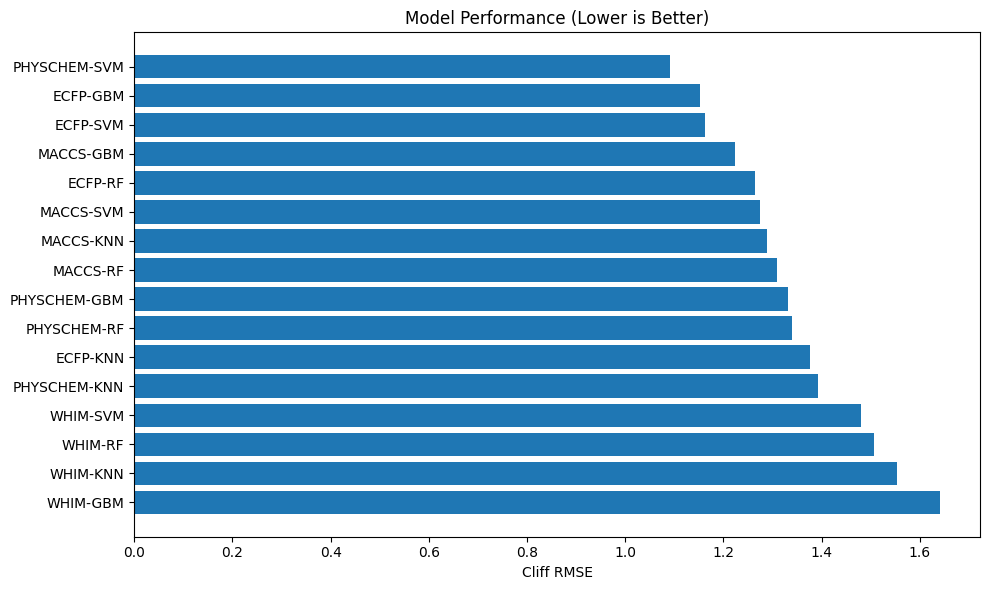

In [33]:
results_df.to_csv(RESULTS_DIR / "ML_model_CHEMBL1978.csv", index=False)
plt.figure(figsize=(10, 6))
plt.barh(
    results_df["Descriptor"] + "-" + results_df["Model"],
    results_df["Cliff_RMSE"]
)
plt.xlabel("Cliff RMSE")
plt.title("Model Performance (Lower is Better)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()